In [2]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [3]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec


# Run scan_L_+=

In [4]:


def calc_NC1_from_data_dict(data_dict):
    h_np = data_dict['hidden_states'][-1].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    return calc_NC1(h_np, y.argmax(1))


In [5]:
# Run scan_L_A.py to generate the results for Fig2.ipynb

# Create an empty DataFrame with the specified headers
df = pd.DataFrame(columns=['L', 'A', 'NC1', 'margins', 'order'])


result_files = glob.glob('./results/sweep_L_A_2d/*')

for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    A = data_dict['C'].max_move
    X = data_dict['X']
    y = data_dict['y']
    loc_y = data_dict['loc_y']
    h_np = data_dict['hidden_states'][-1].cpu().numpy()
    if data_dict['accuracy_l'][-1] < 0.99:
        print(f"A={A}, L={L}, accuracy={data_dict['accuracy_l'][-1]}")
    NC1 = calc_NC1_from_data_dict(data_dict)
    margins = multiclass_functional_margin_from_data_dict(data_dict)[0]
    order = get_r_2(PCA(n_components=2).fit_transform(h_np), loc_y)

    df = pd.concat([df, pd.DataFrame([{
        'L': L,
        'A': A,
        'NC1': NC1,
        'margins': margins,
        'order': 1-order
    }])], ignore_index=True)



  0%|                                                                                                                                                                                                                                                   | 0/90 [00:00<?, ?it/s]

/tmp/ipykernel_3336268/2857873283.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:17<00:00,  5.09it/s]


In [6]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
sns.set_style("whitegrid")


/tmp/ipykernel_3336268/4249669908.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


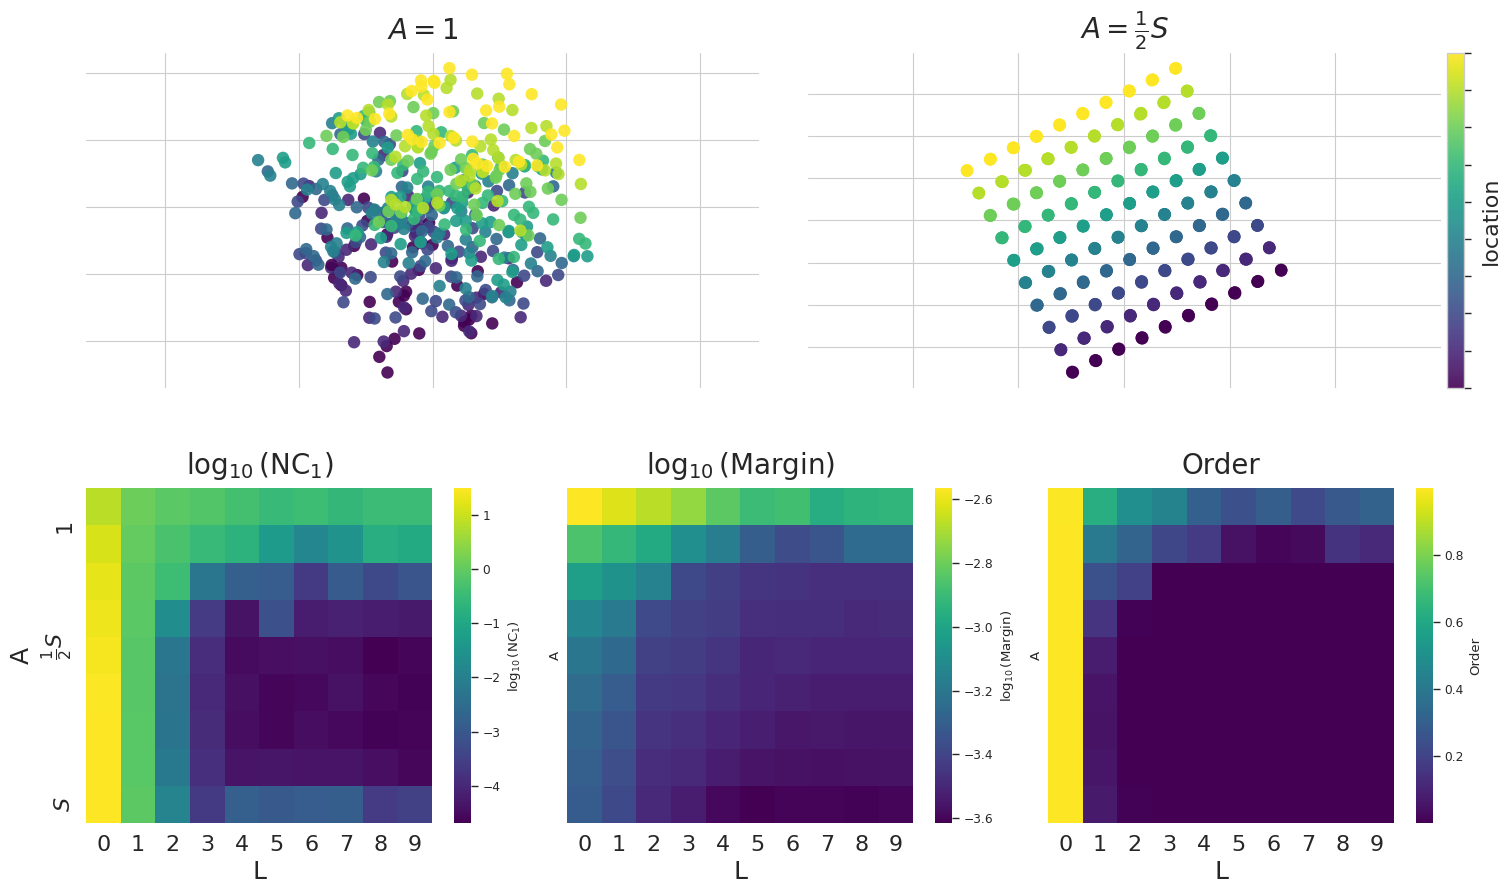

In [7]:
# Ensure L and A are numeric
df['L'] = pd.to_numeric(df['L'])
df['A'] = pd.to_numeric(df['A'])

# Pivot tables for each metric
pivot_NC1 = df.pivot_table(index='A', columns='L', values='NC1', aggfunc='mean')
pivot_margins = df.pivot_table(index='A', columns='L', values='margins', aggfunc='mean')
pivot_order = df.pivot_table(index='A', columns='L', values='order', aggfunc='mean')


# Use the global matplotlib styling set above
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 6, height_ratios=[1, 1], hspace=0.3, wspace=0.25)

# --- First row: 2D PCA plots for two datasets ---

# Load the two specific files
file1 = './results/sweep_L_A_2d/data_max_move_1_L_9.pkl'
file2 = './results/sweep_L_A_2d/data_max_move_5_L_9.pkl'

def plot_pca_subplot(ax, file, title, cb=False):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    h = data_dict['hidden_states'][-1].cpu().numpy()
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    cond = abs(action_taken) <= 1
    # If loc_y is 2D, color by the first dimension
    color = loc_y[:, 0] if loc_y.ndim > 1 else loc_y
    color = color[cond]
    h = h[cond]
    # PCA to 2D
    from sklearn.decomposition import PCA
    h_pca = PCA(n_components=2).fit_transform(h)
    sc = ax.scatter(
        h_pca[:, 0], h_pca[:, 1], c=color, cmap='viridis',
        s=80, alpha=0.9, edgecolor='none'
    )
    ax.set_title(title, fontsize=20, pad=10)
    ax.axis('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    if cb:
        cbar = plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.05)
        cbar.ax.set_yticklabels([])  # Remove colorbar ticks
        cbar.set_label('location', fontsize=16)

ax_pca1 = fig.add_subplot(gs[0, 0:3])
plot_pca_subplot(ax_pca1, file1, r'$A=1$')

ax_pca2 = fig.add_subplot(gs[0, 3:6])
plot_pca_subplot(ax_pca2, file2, r'$A=\frac{1}{2}S$', cb=True)

# --- Second row: original 3 heatmaps ---

axs = [fig.add_subplot(gs[1, i*2:i*2+2]) for i in range(3)]


# For NC1: log10, but avoid log(0) by setting a small floor
pivot_NC1_log = np.log10(np.clip(pivot_NC1, 1e-8, None))
sns.heatmap(
    pivot_NC1_log, ax=axs[0], cmap='viridis', annot=False, fmt=".2f",
    cbar_kws={'label': r'$\log_{10}(\mathrm{NC}_1)$'}
)
axs[0].set_title(r'$\log_{10}(\mathrm{NC}_1)$', fontsize=20, pad=10)
axs[0].set_xlabel('L', fontsize=18)
axs[0].set_ylabel('A', fontsize=18)
axs[0].tick_params(axis='both', which='major', labelsize=16)
S = axs[0].get_yticks()[-1]  # Assuming S is the max y value
axs[0].set_yticks([1, 0.5*S, S])
axs[0].set_yticklabels(['1', r'$\frac{1}{2}S$', r'$S$'])

# For margins: log10, but avoid log(0) by setting a small floor
pivot_margins_log = np.log10(np.clip(pivot_margins, 1e-8, None))
sns.heatmap(
    pivot_margins_log, ax=axs[1], cmap='viridis', annot=False, fmt=".2f",
    cbar_kws={'label': r'$\log_{10}(\mathrm{Margin})$'}
)
axs[1].set_title(r'$\log_{10}(\mathrm{Margin})$', fontsize=20, pad=10)
axs[1].set_xlabel('L', fontsize=18)
axs[1].tick_params(axis='x', which='major', labelsize=16)
axs[1].set_yticks([])
# Set y-ticks: first at 1, middle at 0.5S, last at S

sns.heatmap(
    pivot_order, ax=axs[2], cmap='viridis', annot=False, fmt=".2f",
    cbar_kws={'label': r'Order'}
)
axs[2].set_title('Order', fontsize=20, pad=10)
axs[2].set_xlabel('L', fontsize=18)
axs[2].tick_params(axis='x', which='major', labelsize=16)
axs[2].set_yticks([])

plt.tight_layout()
os.makedirs('./final_results/figures', exist_ok=True)
fig.savefig('./final_results/figures/fig5.png', dpi=300)
plt.show()
